### **BrainTumor MRI Scan**

# Import Dataset from kaggle

In [ ]:
!pip install kaggle


# Move & set permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d rm1000/brain-tumor-mri-scans

!unzip brain-tumor-mri-scans.zip -d brain_tumor_data

Streaming output truncated to the last 5000 lines.
  inflating: brain_tumor_data/healthy/0402.jpg  
  inflating: brain_tumor_data/healthy/0403.jpg  
  inflating: brain_tumor_data/healthy/0404.jpg  
  inflating: brain_tumor_data/healthy/0405.jpg  
  inflating: brain_tumor_data/healthy/0406.jpg  
  inflating: brain_tumor_data/healthy/0407.jpg  
  inflating: brain_tumor_data/healthy/0408.jpg  
  inflating: brain_tumor_data/healthy/0409.jpg  
  inflating: brain_tumor_data/healthy/0410.jpg  
  inflating: brain_tumor_data/healthy/0411.jpg  
  inflating: brain_tumor_data/healthy/0412.jpg  
  inflating: brain_tumor_data/healthy/0413.jpg  
  inflating: brain_tumor_data/healthy/0414.jpg  
  inflating: brain_tumor_data/healthy/0415.jpg  
  inflating: brain_tumor_data/healthy/0416.jpg  
  inflating: brain_tumor_data/healthy/0417.jpg  
  inflating: brain_tumor_data/healthy/0418.jpg  
  inflating: brain_tumor_data/healthy/0419.jpg  
  inflating: brain_tumor_data/healthy/0420.jpg  
  inflating: brain

# Installing Necessary Libraries

In [ ]:
!pip install tensorflow

## **BrainTumor classification By ResNet18 & DeseNet**

# Installing Libraries

In [ ]:
!pip install opencv-python

In [ ]:
import os
import cv2
import numpy as np
import torch
from torchvision import models
from torchvision import transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report,precision_score, recall_score, f1_score, accuracy_score
import torch.optim as optim
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt
import math
import seaborn as sns
from PIL import Image
from copy import deepcopy
import random
import time
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cpu


# Dataset

In [ ]:
# Custom Dataset class
class BrainTumorDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        # load the images and labels
        self.images, self.labels = self.load_images_and_labels()
        # encode the labels
        self.le = LabelEncoder()
        self.labels = self.le.fit_transform(self.labels)

    def load_images_and_labels(self):
        images, labels = [], []
        for label in os.listdir(self.data_dir):
            folder_path = os.path.join(self.data_dir, label)
            for img_file in os.listdir(folder_path):
                img_path = os.path.join(folder_path, img_file)
                img = cv2.imread(img_path)
                images.append(img)
                labels.append(label)
        return images, labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        return img, label

    def labels_inverse_transform(self, labels):
        return self.le.inverse_transform(labels)

# Create the dataset and plot a few images

In [ ]:
# Define transformations
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # pretrained resnet normalization
])
# Create dataset and dataloaders
dataset = BrainTumorDataset("/content/brain_tumor_data", transform=transform)

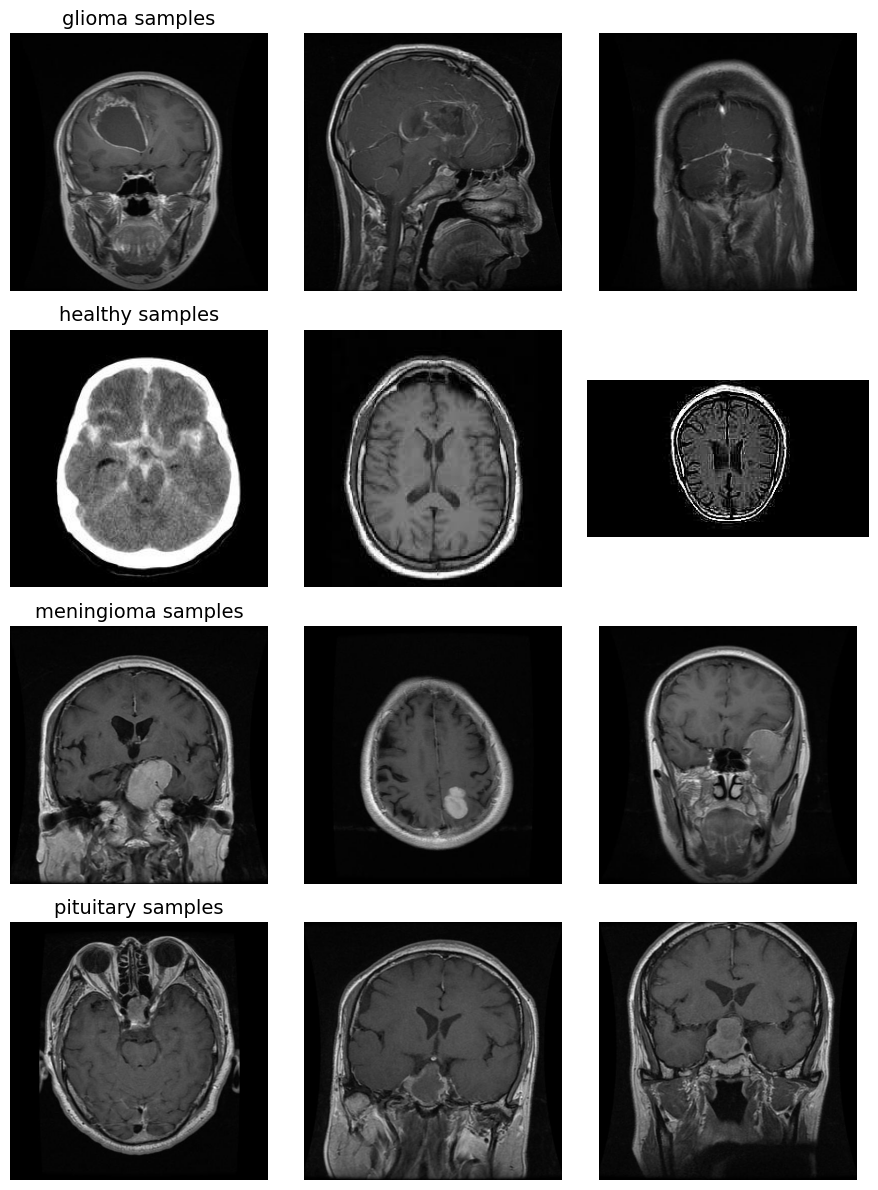

In [ ]:
def show_class_samples(dataset, classes, num_samples=3):
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(num_samples * 3, len(classes) * 3))
    for i, cls in enumerate(classes):
        class_dir = os.path.join(dataset, cls) # data_dir should be a path to the dataset directory.
        images = random.sample(os.listdir(class_dir), num_samples)
        for j, img_name in enumerate(images):
            img_path = os.path.join(class_dir, img_name)
            img = Image.open(img_path)
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                 axes[i, j].set_title(f"{cls} samples", fontsize=14)
    plt.tight_layout()
    plt.show()

classes = ['glioma', 'healthy', 'meningioma', 'pituitary']
show_class_samples("/content/brain_tumor_data", classes) # Pass the dataset path instead of the dataset object.

In [ ]:
def plot_images(images, labels, predictions=None, denormalize=None, img_size=4, hspace=0.9):
    N = len(images)
    ncols = 2 if N > 1 else 1
    nrows = math.ceil(N/2) if N else 1
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*img_size, nrows*img_size))
    for idx, image in enumerate(images):
        title = f"label={labels[idx]}"
        if predictions is not None:
            title += f"\nprediction={predictions[idx]}"

        if denormalize is not None:
            image = denormalize(image)

        image = image.cpu().numpy().transpose((1, 2, 0))
        if N == 1:
            axes.imshow(image)
            axes.set_title(title)
        else:
            i, j = idx // 2, idx % 2
            axes[i, j].imshow(image)
            axes[i, j].set_title(title)
    plt.subplots_adjust(hspace=hspace)
    plt.show()

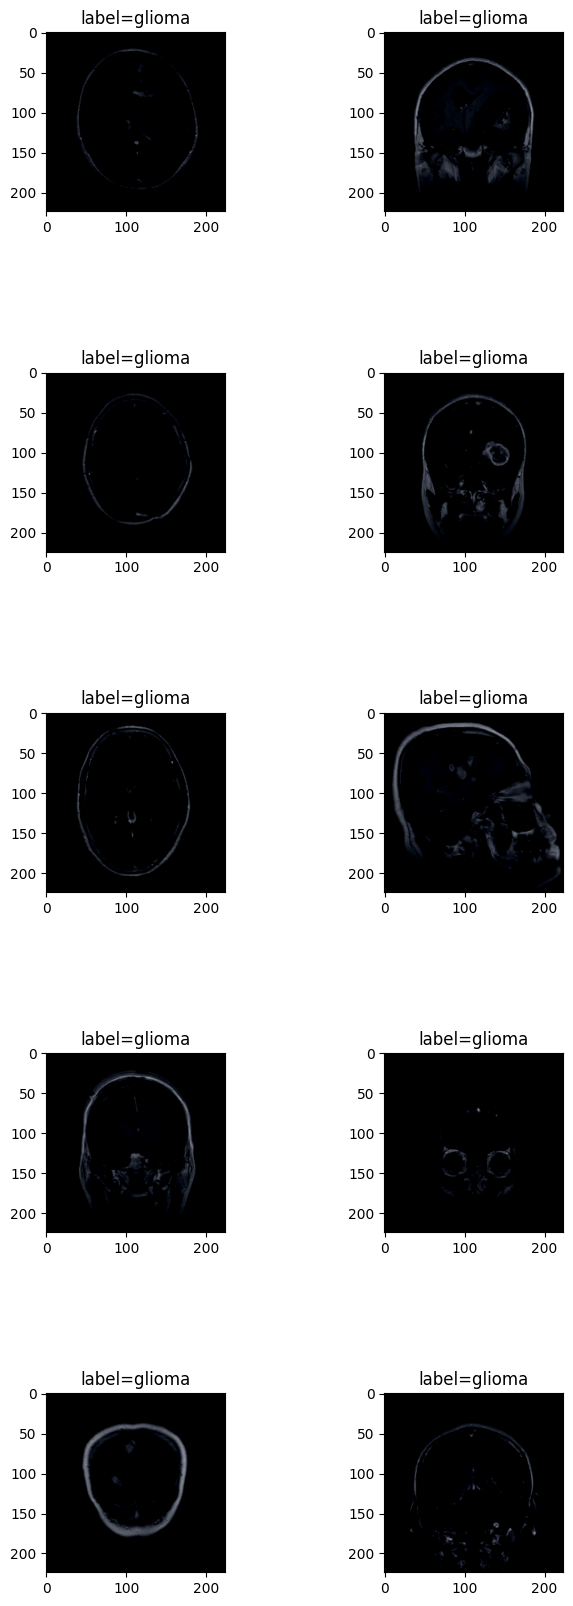

In [ ]:
images, labels = zip(*[dataset[i] for i in range(10)])
plot_images(images, dataset.labels_inverse_transform(labels), predictions=None, denormalize=transforms.Normalize(mean=[-0.485, -0.456, -0.406], std=[1/0.229, 1/0.224, 1/0.225]))

# Splitting dataset into train, validation and test

In [ ]:
dataset_n = len(dataset)
print(f"total_samples={dataset_n}")
print(f"65%={dataset_n*0.65}")
print(f"15%={dataset_n*0.15}")
print(f"20%={dataset_n*0.2}")

total_samples=7023
65%=4564.95
15%=1053.45
20%=1404.6000000000001


In [ ]:
train_dataset, val_dataset, test_dataset = random_split(dataset, lengths=[4565, 1053, 1405])
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# don't shuffle validation and test sets.
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
np.arange(16).reshape((4,4)).mean(axis=0)

array([6., 7., 8., 9.])

# Model ResNet18

# Train the model

In [ ]:
def print_logs(logs, main_msg=""):
    if main_msg:
        print(main_msg)
    for k, v in logs.items():
        print(f"\t* {k} {v}")


def run_epoch(dataloader, model, optimizer, criterion, device, training=True):
    if training:
        model.train()

    running_loss = 0.0
    confusion_matrix = np.zeros((4, 4))
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        # zero out gradients
        optimizer.zero_grad()

        # forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # backward pass and optimization step
        loss.backward()
        optimizer.step()

        # update running loss and confusion matrix
        running_loss += loss.item()

        _, preds = torch.max(outputs.data, 1)
        for y_true in range(4):
            for y_pred in range(4):
                confusion_matrix[y_true, y_pred] += (preds[labels == y_true] == y_pred).sum().item()

    epoch_loss = running_loss/len(dataloader)
    recall = np.diag(confusion_matrix) / confusion_matrix.sum(axis=1)
    precision = np.diag(confusion_matrix) / confusion_matrix.sum(axis=0)
    f1 = 2 * recall * precision / (recall + precision)
    return {"loss": epoch_loss, "recall": recall, "precision": precision, "f1_score": f1}


def update_logs(logs, epoch_logs, epoch_type="train"):
    for k, v in epoch_logs.items():
        if k not in logs[epoch_type]:
            logs[epoch_type][k] = []
        logs[epoch_type][k].append(v)


def train_model(train_loader, val_loader, test_loader, model, optimizer, criterion, n_epochs, device, early_stopping=10):
    best_model, best_val_loss, no_progress = None, np.inf, 0
    logs = {"train": dict(), "val": dict(), "test": dict()}
    model = model.to(device)
    for epoch in range(n_epochs):
        model.train()
        # train epoch
        train_logs = run_epoch(train_loader, model, optimizer, criterion, device, training=True)
        print_logs(train_logs, main_msg=f"Train Logs/ Epoch {epoch + 1}")
        update_logs(logs, train_logs, epoch_type="train")

        model.eval()
        # val epoch
        val_logs = run_epoch(val_loader, model, optimizer, criterion, device, training=False)
        print_logs(val_logs, main_msg=f"Val Logs/ Epoch {epoch + 1}")
        update_logs(logs, val_logs, epoch_type="val")
        # test epoch
        test_logs = run_epoch(test_loader, model, optimizer, criterion, device, training=False)
        print_logs(test_logs, main_msg=f"Test Logs/ Epoch {epoch + 1}")
        update_logs(logs, test_logs, epoch_type="test")

        # update best model and check for early stopping
        if val_logs["loss"] < best_val_loss:
            best_val_loss = val_logs["loss"]
            no_progress = 0
            best_model = deepcopy(model)
        else:
            no_progress += 1
            if no_progress == early_stopping:
                break
        print("=" * 100)
    return best_model, logs


def eval_model(dataloader, model, optimizer, criterion, device):
    model.eval()
    eval_logs = run_epoch(dataloader, model, optimizer, criterion, device, training=False)
    print_logs(eval_logs, "Best Model Evaluation:")


def run_training(train_loader, val_loader, test_loader, model, optimizer, criterion, n_epochs, device, early_stopping=10):
    best_model, logs = train_model(train_loader=train_loader, val_loader=val_loader, test_loader=test_loader,model=model, optimizer=optimizer, criterion=criterion, n_epochs=n_epochs, device=device, early_stopping=early_stopping)
    return best_model, logs

In [ ]:


def print_logs(logs, main_msg=""):
    if main_msg:
        print(main_msg)
    for k, v in logs.items():
        print(f"\t* {k} {v}")


def run_epoch(dataloader, model, optimizer, criterion, device, training=True):
    if training:
        model.train()

    running_loss = 0.0
    confusion_matrix = np.zeros((4, 4))
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        # zero out gradients
        optimizer.zero_grad()

        # forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # backward pass and optimization step
        if training:  # Only perform backpropagation and optimization during training
            loss.backward()
            optimizer.step()

        # update running loss and confusion matrix
        running_loss += loss.item()

        _, preds = torch.max(outputs.data, 1)
        for y_true in range(4):
            for y_pred in range(4):
                confusion_matrix[y_true, y_pred] += (preds[labels == y_true] == y_pred).sum().item()

    epoch_loss = running_loss / len(dataloader)
    recall = np.diag(confusion_matrix) / confusion_matrix.sum(axis=1)
    precision = np.diag(confusion_matrix) / confusion_matrix.sum(axis=0)
    f1 = 2 * recall * precision / (recall + precision)
    return {"loss": epoch_loss, "recall": recall, "precision": precision, "f1_score": f1}


def update_logs(logs, epoch_logs, epoch_type="train"):
    for k, v in epoch_logs.items():
        if k not in logs[epoch_type]:
            logs[epoch_type][k] = []
        logs[epoch_type][k].append(v)


def train_model(train_loader, val_loader, test_loader, model, optimizer, criterion, n_epochs, device, early_stopping=10):
    best_model, best_val_loss, no_progress = None, np.inf, 0
    logs = {"train": dict(), "val": dict(), "test": dict()}
    model = model.to(device)
    for epoch in range(n_epochs):
        model.train()
        # train epoch
        train_logs = run_epoch(train_loader, model, optimizer, criterion, device, training=True)
        print_logs(train_logs, main_msg=f"Train Logs/ Epoch {epoch + 1}")
        update_logs(logs, train_logs, epoch_type="train")

        model.eval()
        # val epoch
        val_logs = run_epoch(val_loader, model, optimizer, criterion, device, training=False)
        print_logs(val_logs, main_msg=f"Val Logs/ Epoch {epoch + 1}")
        update_logs(logs, val_logs, epoch_type="val")
        # test epoch
        test_logs = run_epoch(test_loader, model, optimizer, criterion, device, training=False)
        print_logs(test_logs, main_msg=f"Test Logs/ Epoch {epoch + 1}")
        update_logs(logs, test_logs, epoch_type="test")

        # update best model and check for early stopping
        if val_logs["loss"] < best_val_loss:
            best_val_loss = val_logs["loss"]
            no_progress = 0
            best_model = deepcopy(model)  # Use deepcopy to create a new copy of the model
        else:
            no_progress += 1
            if no_progress == early_stopping:
                break
        print("=" * 100)
    return best_model, logs


def eval_model(dataloader, model, optimizer, criterion, device):
    model.eval()
    eval_logs = run_epoch(dataloader, model, optimizer, criterion, device, training=False)
    print_logs(eval_logs, "Best Model Evaluation:")




In [ ]:

# Function to run training and measure performance
def run_training(train_loader, val_loader, test_loader, model, optimizer, criterion, n_epochs, device, early_stopping=10):
    start_time = time.time()  # Track training start time
    best_model, logs = train_model(train_loader=train_loader, val_loader=val_loader, test_loader=test_loader, model=model, optimizer=optimizer, criterion=criterion, n_epochs=n_epochs, device=device, early_stopping=early_stopping)
    end_time = time.time()  # Track training end time
    training_time = end_time - start_time
    return best_model, logs, training_time

# Load ResNet18 with pretrained weights
model_resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all layers except the fully connected layer
for param in model_resnet.parameters():
    param.requires_grad = False

# Replace the classifier (fully connected layer)
model_resnet.fc = torch.nn.Linear(in_features=512, out_features=4, bias=True)

# Define optimizer for ResNet18
optimizer_resnet = optim.Adam(params=filter(lambda p: p.requires_grad, model_resnet.parameters()), lr=1e-3)

# Define loss function for ResNet18
criterion_resnet = torch.nn.CrossEntropyLoss()

# Train the ResNet model and measure training time
best_model_resnet, logs_resnet, training_time_resnet = run_training(train_loader=train_loader,
                                        val_loader=val_loader,
                                        test_loader=test_loader,
                                        model=model_resnet,
                                        optimizer=optimizer_resnet,
                                        criterion=criterion_resnet,
                                        n_epochs=10,
                                        device=device)

# Load DenseNet121 with pretrained weights
model_densenet = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

# Freeze all layers except the final classification layer
for param in model_densenet.parameters():
    param.requires_grad = False

# Replace the classifier (fully connected layer)
model_densenet.classifier = torch.nn.Linear(in_features=1024, out_features=4, bias=True)

# Define optimizer for DenseNet121
optimizer_densenet = optim.Adam(params=filter(lambda p: p.requires_grad, model_densenet.parameters()), lr=1e-3)

# Define loss function for DenseNet121
criterion_densenet = torch.nn.CrossEntropyLoss()

# Train the DenseNet model and measure training time
best_model_densenet, logs_densenet, training_time_densenet = run_training(train_loader=train_loader,
                                        val_loader=val_loader,
                                        test_loader=test_loader,
                                        model=model_densenet,
                                        optimizer=optimizer_densenet,
                                        criterion=criterion_densenet,
                                        n_epochs=10,
                                        device=device)







Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 95.0MB/s]


Train Logs/ Epoch 1
	* loss 0.71914131616379
	* recall [0.66248795 0.87954545 0.54779412 0.83303571]
	* precision [0.78874856 0.82398864 0.61190965 0.71167048]
	* f1_score [0.72012579 0.85086112 0.57807953 0.76758536]
Val Logs/ Epoch 1
	* loss 0.4593737856908278
	* recall [0.84978541 0.95652174 0.56431535 0.98214286]
	* precision [0.85344828 0.90793651 0.80952381 0.81360947]
	* f1_score [0.8516129  0.93159609 0.66503667 0.88996764]
Test Logs/ Epoch 1
	* loss 0.4736524373292923
	* recall [0.86609687 0.94225722 0.51898734 0.97478992]
	* precision [0.84210526 0.90656566 0.8        0.78555305]
	* f1_score [0.85393258 0.92406692 0.62955854 0.87      ]
Train Logs/ Epoch 2
	* loss 0.44236317287375043
	* recall [0.79845709 0.93484848 0.70036765 0.91517857]
	* precision [0.86610879 0.91679049 0.72988506 0.84085316]
	* f1_score [0.83090818 0.92573143 0.71482176 0.87644292]
Val Logs/ Epoch 2
	* loss 0.3731759551799659
	* recall [0.86695279 0.97324415 0.62240664 0.96071429]
	* precision [0.8898678

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 124MB/s]


Train Logs/ Epoch 1
	* loss 0.7163612334044663
	* recall [0.70009643 0.86439394 0.57261029 0.81071429]
	* precision [0.75625    0.80295567 0.61805556 0.77210884]
	* f1_score [0.72709064 0.83254287 0.59446565 0.79094077]
Val Logs/ Epoch 1
	* loss 0.4552319790377761
	* recall [0.91416309 0.92307692 0.593361   0.925     ]
	* precision [0.82879377 0.91694352 0.78142077 0.83012821]
	* f1_score [0.86938776 0.92       0.6745283  0.875     ]
Test Logs/ Epoch 1
	* loss 0.44207150353626773
	* recall [0.90883191 0.93963255 0.5664557  0.94397759]
	* precision [0.82642487 0.92746114 0.78854626 0.83004926]
	* f1_score [0.86567164 0.93350717 0.65930018 0.88335518]
Train Logs/ Epoch 2
	* loss 0.4166887854779517
	* recall [0.82642237 0.94090909 0.734375   0.91964286]
	* precision [0.87807377 0.92068199 0.76679463 0.85976628]
	* f1_score [0.85146547 0.93068565 0.75023474 0.88869715]
Val Logs/ Epoch 2
	* loss 0.3544801311059432
	* recall [0.89270386 0.94314381 0.7219917  0.91785714]
	* precision [0.89655

In [ ]:
probabilities = []
for y in np.unique(dataset.labels):
    count = np.sum(dataset.labels == y)
    probabilities.append(count)
    print(f"{dataset.labels_inverse_transform([y])[0]} has {count} samples")
probabilities = probabilities / np.sum(probabilities)

glioma has 1621 samples
healthy has 2000 samples
meningioma has 1645 samples
pituitary has 1757 samples


In [ ]:
def plot_logs(logs, weights):
    for key, sub_logs in logs.items():
        fig, axes= plt.subplots(nrows=1, ncols=len(sub_logs.keys()), figsize=(5 * len(sub_logs.keys()), 4))
        fig.suptitle(f"{key} per-class metrics")
        for idx, metric in enumerate(sub_logs.keys()):
            values = sub_logs[metric]
            if isinstance(values[0], np.ndarray):
                values = np.vstack(values)
                for y in range(values.shape[1]):
                    axes[idx].plot(values[:, y], marker="x", label=dataset.labels_inverse_transform([y])[0])
                    axes[idx].legend()
            else:
                axes[idx].plot(values, marker="x")
            axes[idx].set_title(metric)
            axes[idx].grid()
            axes[idx].set_xlabel("epoch")
            axes[idx].set_ylabel(metric)
        plt.show()
        plt.close()

        fig, axes= plt.subplots(nrows=1, ncols=len(sub_logs.keys()), figsize=(5 * len(sub_logs.keys()), 4))
        fig.suptitle(f"{key} class average metrics")
        for idx, metric in enumerate(sub_logs.keys()):
            values = sub_logs[metric]
            if isinstance(values[0], np.ndarray):
                values = np.vstack(values) * np.array(weights).reshape((1, -1))
                values = values.sum(axis=1)
            axes[idx].plot(values, marker="x")
            axes[idx].set_title(metric)
            axes[idx].grid()
            axes[idx].set_xlabel("epoch")
            axes[idx].set_ylabel(metric)
        plt.show()
        plt.close()

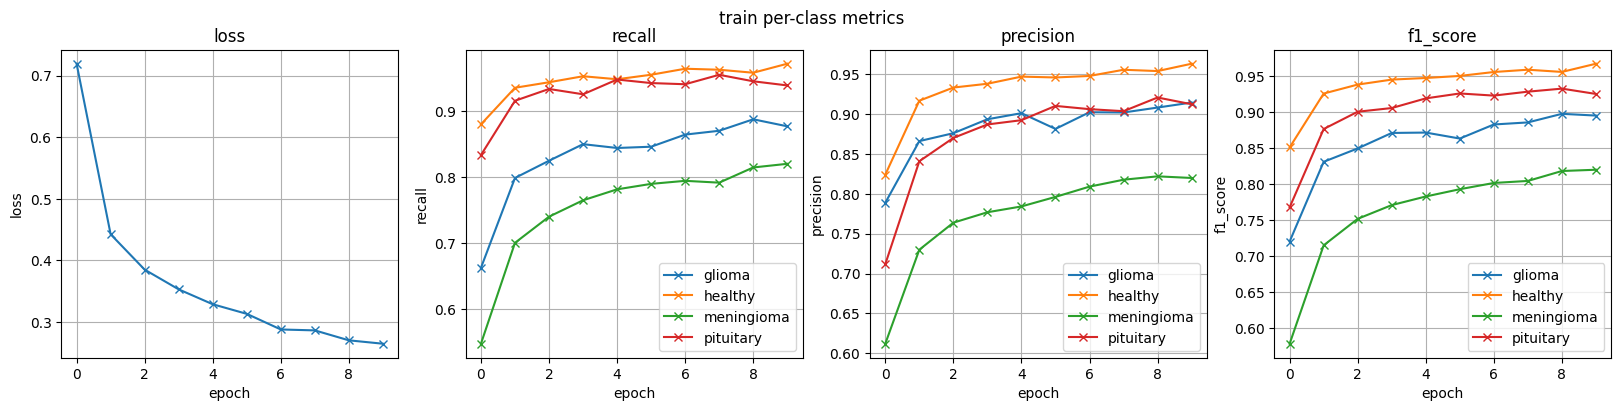

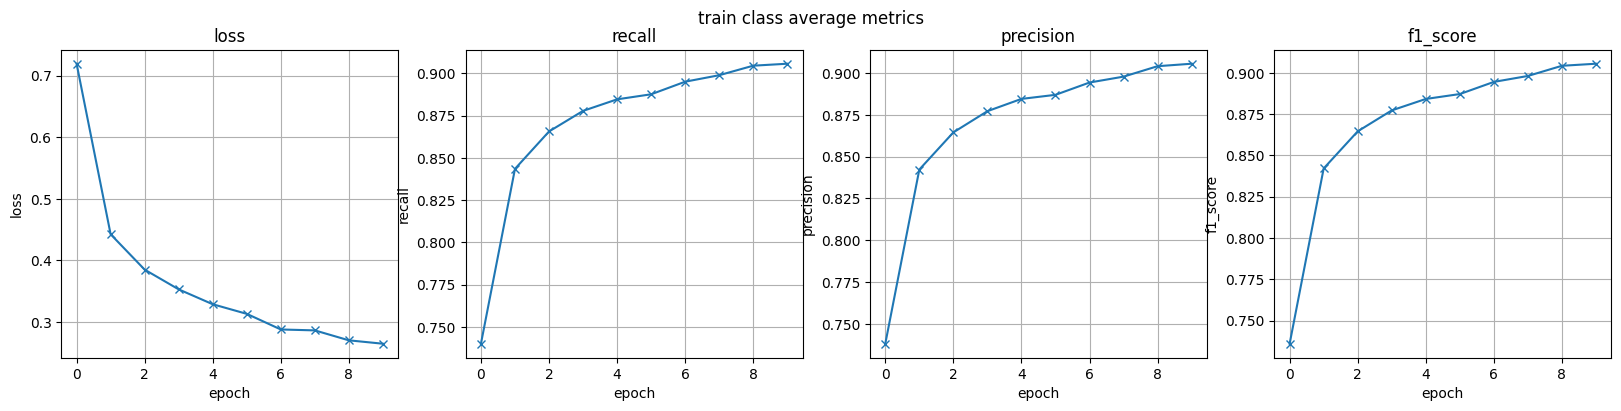

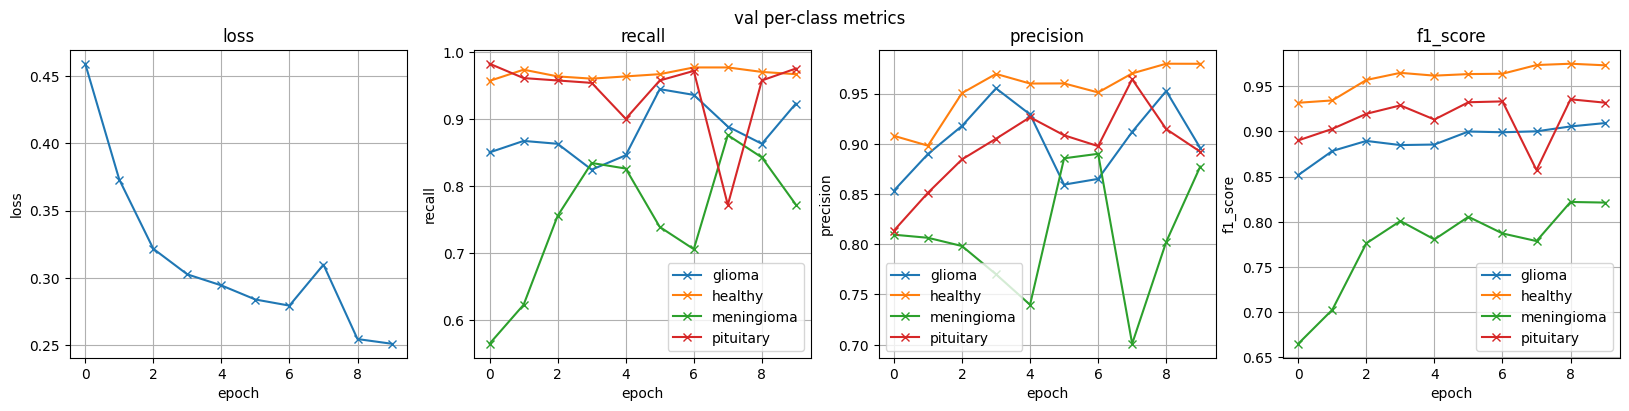

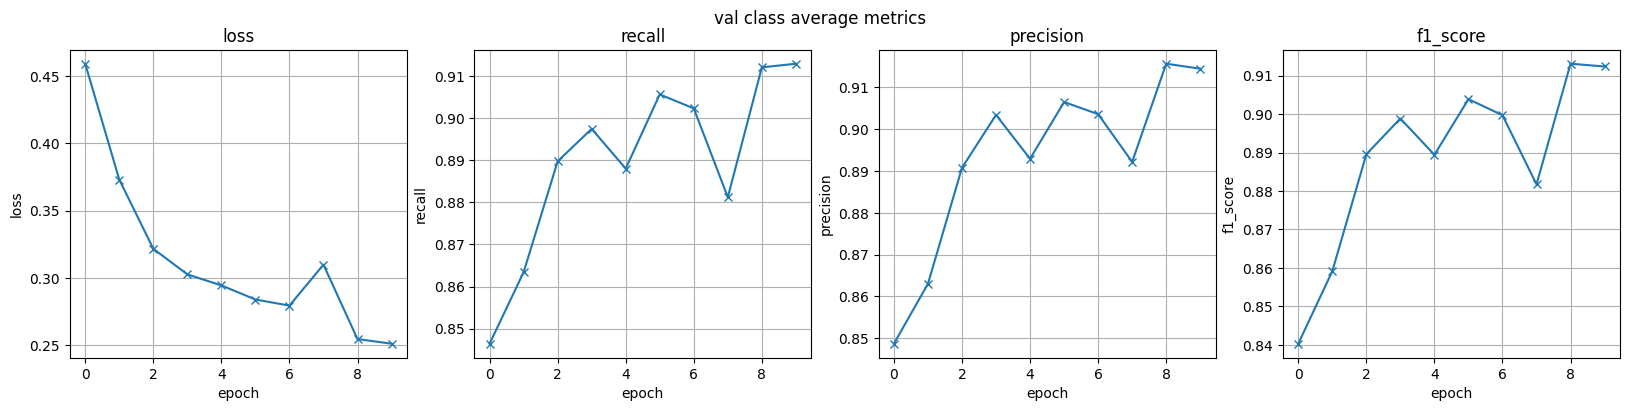

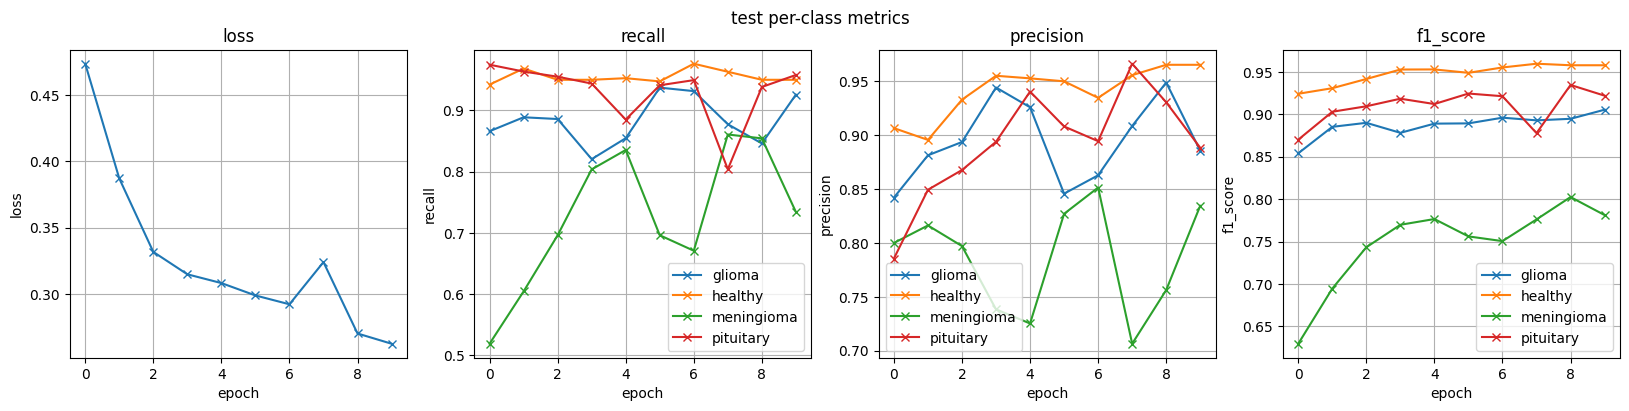

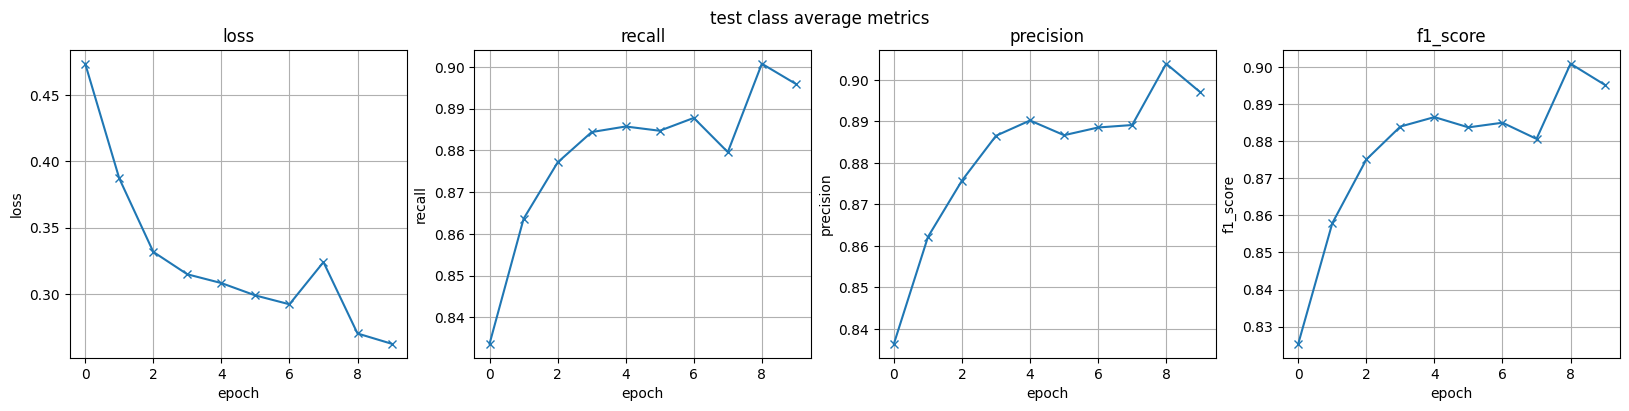

In [ ]:
plot_logs(logs_resnet, weights=probabilities) # Pass logs_resnet instead of best_model_resnet

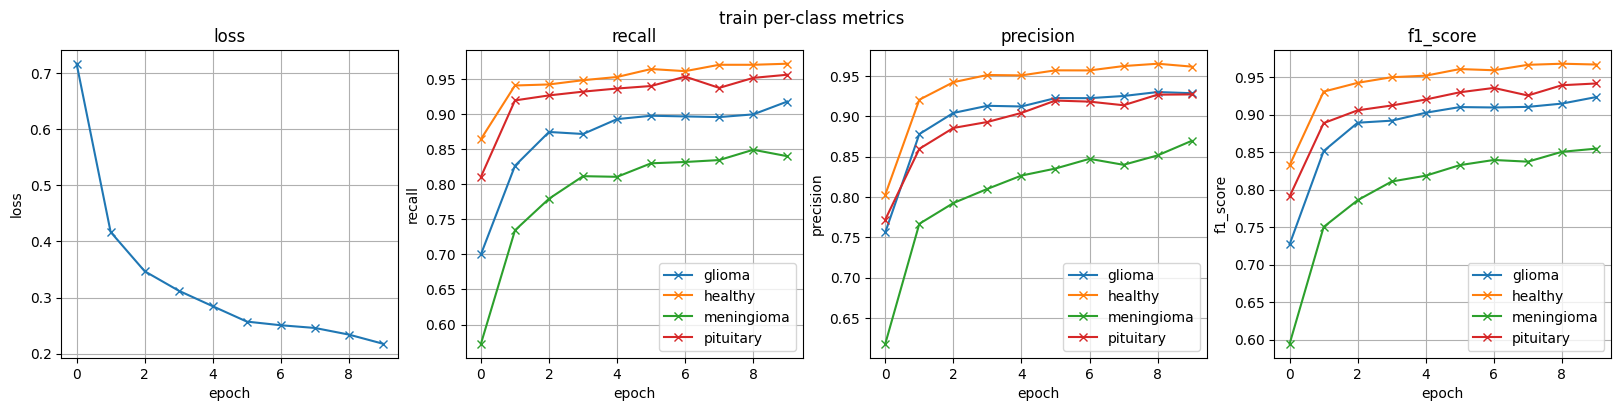

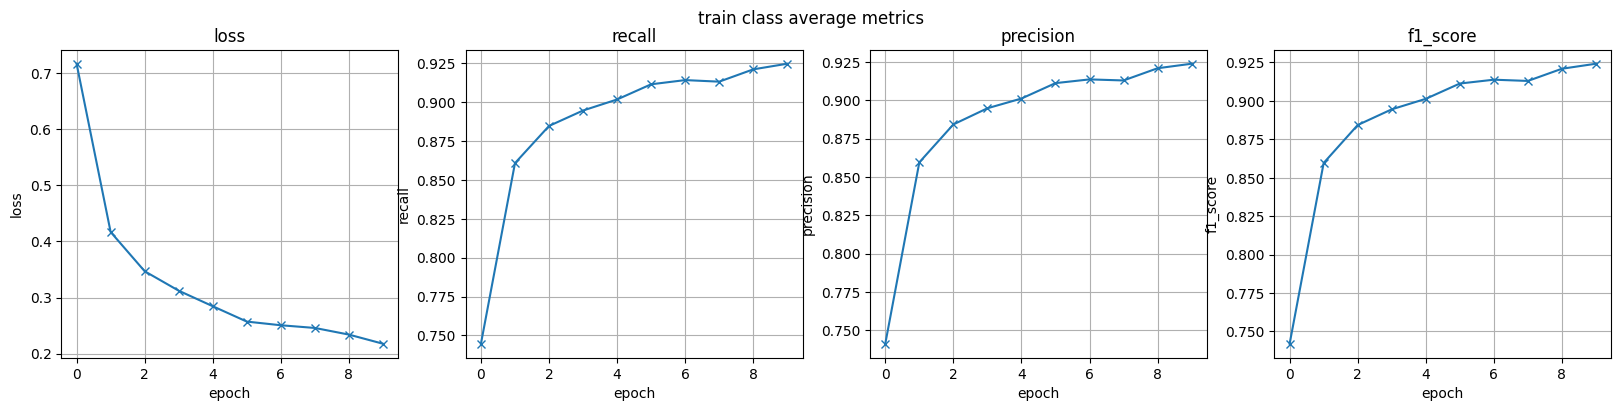

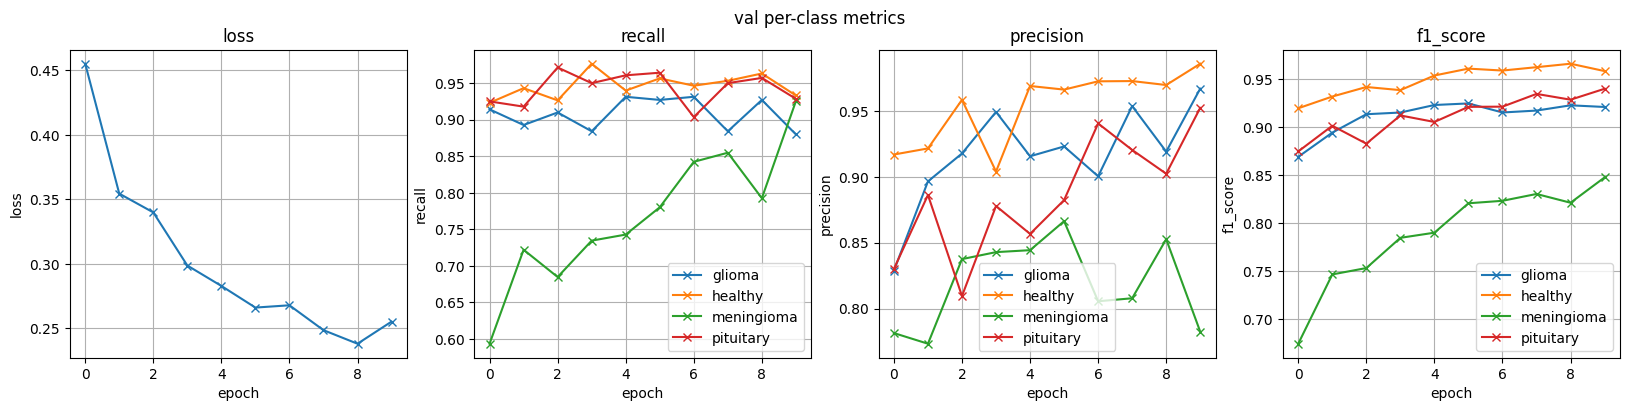

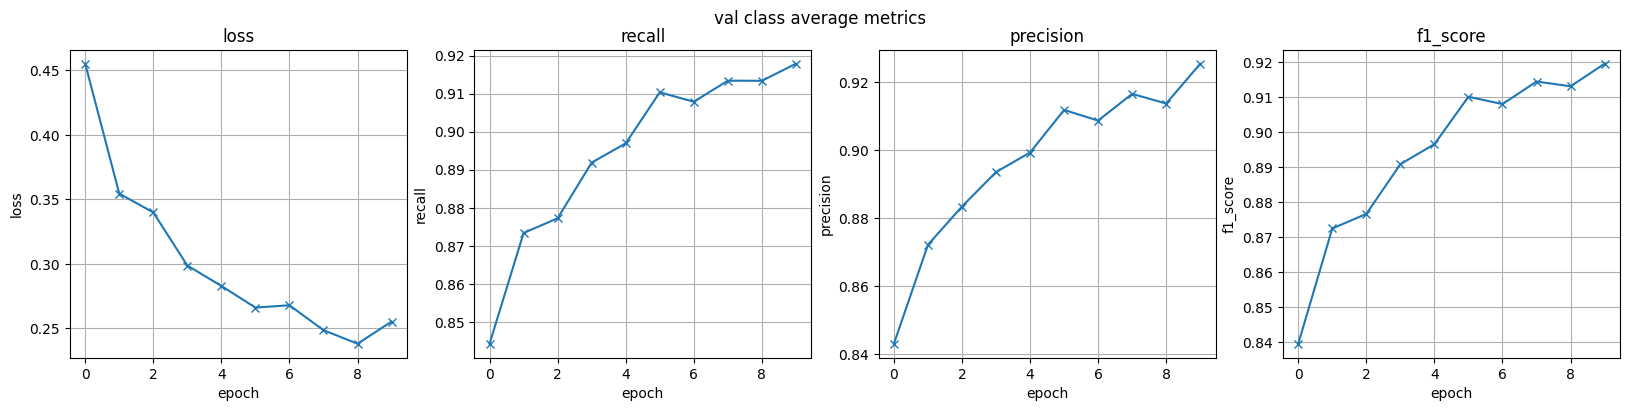

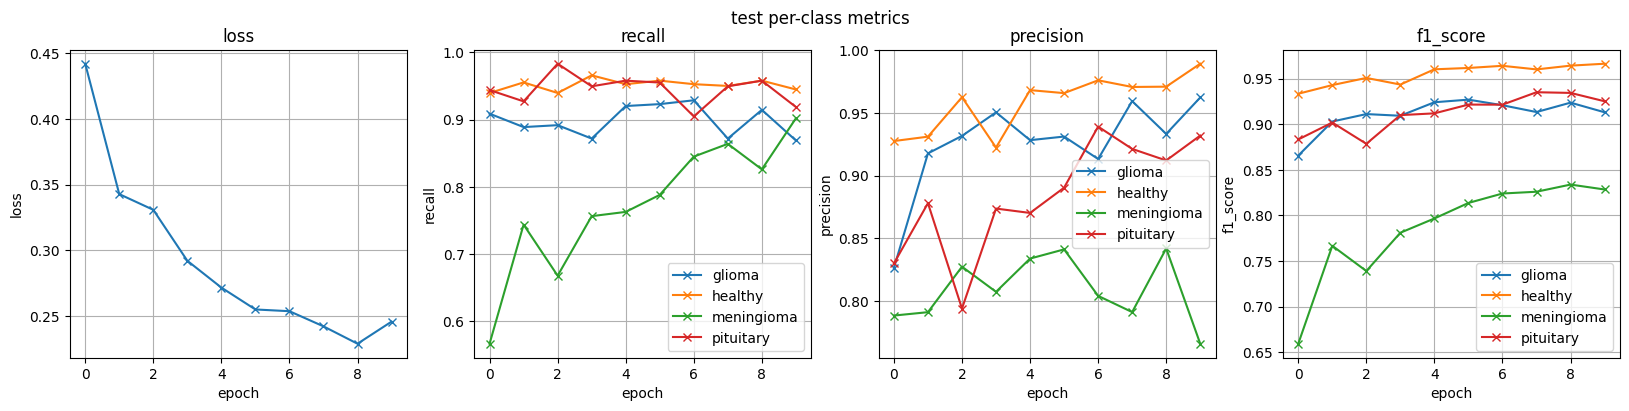

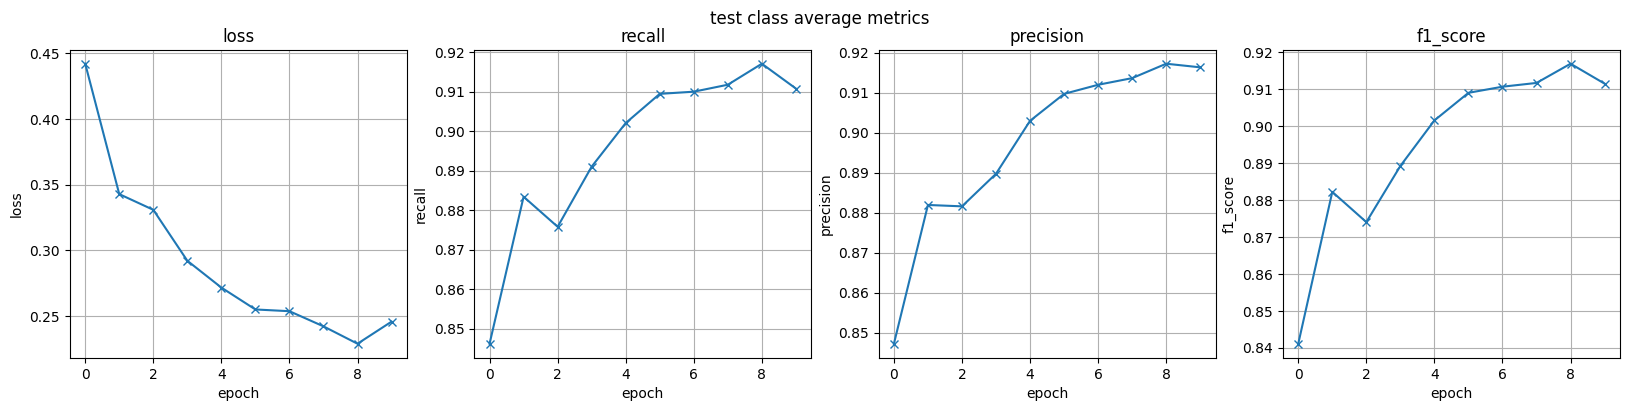

In [ ]:
plot_logs(logs_densenet, weights=probabilities)  # Changed best_model_densenet to logs_densenet

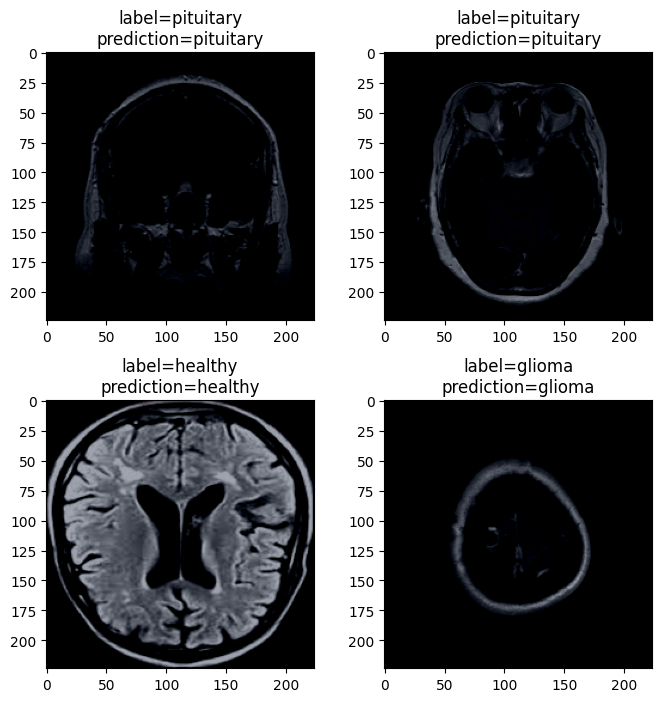

In [ ]:
best_model_resnet.eval()

# Get a batch of images from the test set
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# Select 4 random images
indices = np.random.choice(a=np.arange(len(images)), size=4, replace=False).astype(np.int64)
images = images[indices]
labels = labels[indices]

# Get model predictions
outputs = best_model_resnet(images) # Use transfer_learning_best_model here
_, preds = torch.max(outputs, 1)  # get the predicted class indices

plot_images(images.cpu(), dataset.labels_inverse_transform(labels.cpu().numpy()), predictions=dataset.labels_inverse_transform(preds.cpu().numpy()),
            denormalize=transforms.Normalize(mean=[-0.485, -0.456, -0.406], std=[1/0.229, 1/0.224, 1/0.225]), hspace=0.3)

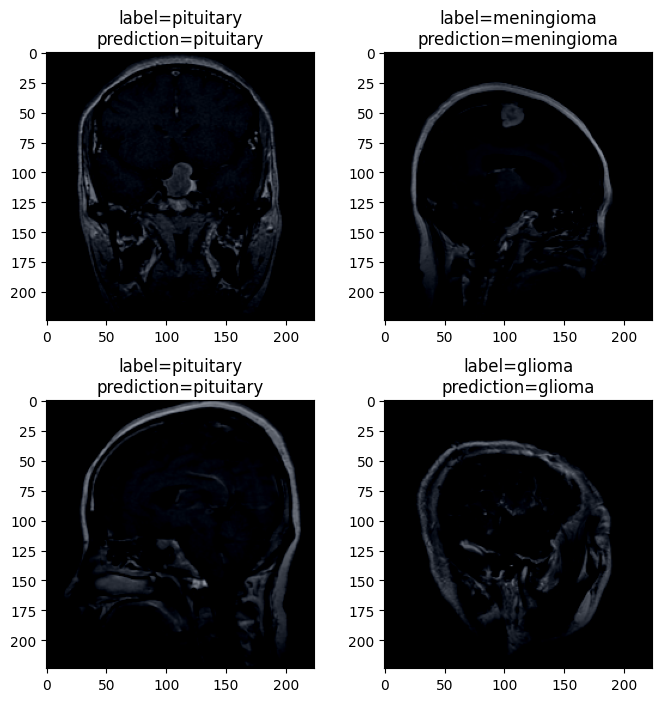

In [ ]:
best_model_densenet.eval()

# Get a batch of images from the test set
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# Select 4 random images
indices = np.random.choice(a=np.arange(len(images)), size=4, replace=False).astype(np.int64)
images = images[indices]
labels = labels[indices]

# Get model predictions
outputs = best_model_densenet(images) # Use transfer_learning_best_model here
_, preds = torch.max(outputs, 1)  # get the predicted class indices

plot_images(images.cpu(), dataset.labels_inverse_transform(labels.cpu().numpy()), predictions=dataset.labels_inverse_transform(preds.cpu().numpy()),
            denormalize=transforms.Normalize(mean=[-0.485, -0.456, -0.406], std=[1/0.229, 1/0.224, 1/0.225]), hspace=0.3)

# Result / Performance of Model On Brain Tumor dataset

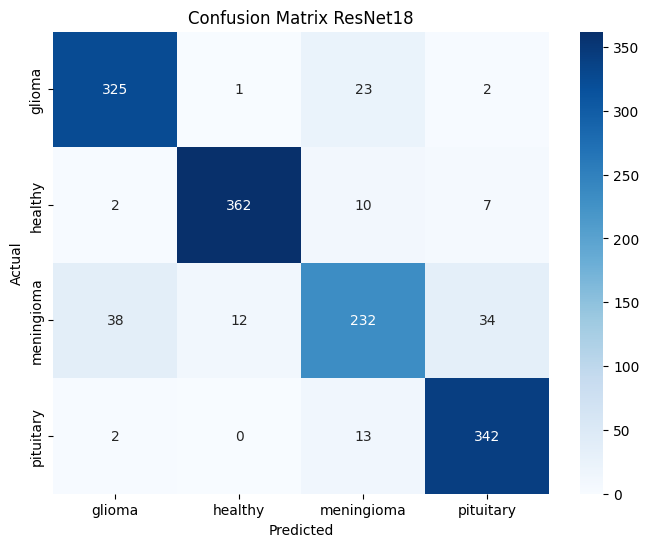

Classification Report of ResNet18:
              precision    recall  f1-score   support

      glioma       0.89      0.93      0.91       351
     healthy       0.97      0.95      0.96       381
  meningioma       0.83      0.73      0.78       316
   pituitary       0.89      0.96      0.92       357

    accuracy                           0.90      1405
   macro avg       0.89      0.89      0.89      1405
weighted avg       0.90      0.90      0.90      1405



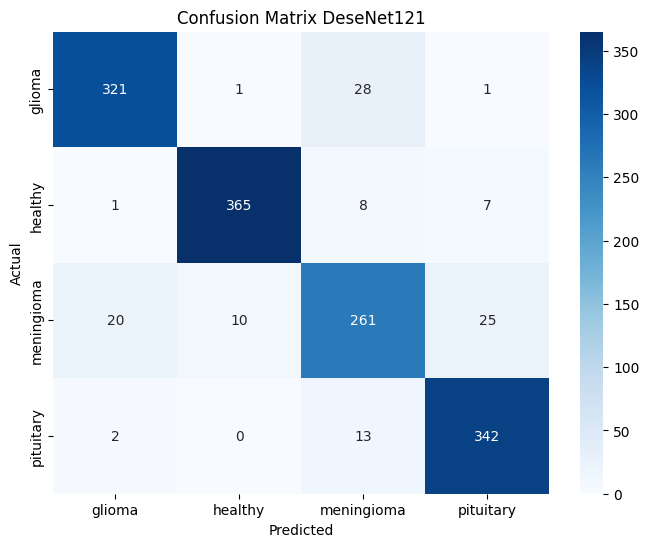

Classification Report of DesNet121:
              precision    recall  f1-score   support

      glioma       0.93      0.91      0.92       351
     healthy       0.97      0.96      0.96       381
  meningioma       0.84      0.83      0.83       316
   pituitary       0.91      0.96      0.93       357

    accuracy                           0.92      1405
   macro avg       0.91      0.91      0.91      1405
weighted avg       0.92      0.92      0.92      1405



In [ ]:
def plot_confusion_matrix(model, data_loader, classes, device, model_name): # Added model_name parameter
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix {model_name}') # Use model_name in title
    plt.show()
    return all_preds, all_labels

classes = ['glioma', 'healthy', 'meningioma', 'pituitary']

# Plot confusion matrix for ResNet18
all_preds_resnet, all_labels_resnet = plot_confusion_matrix(best_model_resnet, test_loader, classes, device, "ResNet18")

print('Classification Report of ResNet18:')
print(classification_report(all_labels_resnet, all_preds_resnet, target_names=classes))

# Plot confusion matrix for DeseNet121
all_preds_desenet, all_labels_desenet = plot_confusion_matrix(best_model_densenet, test_loader, classes, device, "DeseNet121") # Call with "DeseNet121"

print('Classification Report of DesNet121:')
print(classification_report(all_labels_desenet, all_preds_desenet, target_names=classes))